Import all necessary python libraries.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
import os
from pathlib import Path
import numpy as np
import itertools

# background of the experiment


We have recorded flow cytometry data for several strains.

In all cases, we removed the old carbon source, and cells were shifted to galactose growth (either 2 or 0.2%) at the start of the experiment.

So we are expecting that they will start to express genes in the gal cluster to make use of the new carbon source.

Two strains carry either the Gal1p (YET911) or DOA1p (YET937) tagged with mScarlet.

This means, that when the cells induce the expression of GAL1, they will also start producing mScalet.

The mScarlet we can see as an increase in fluorescence.

We also included the YET938 strain, DOA1 tagged with mScarlet under the GAL1 promoter.

The last strain is the WT strain (untagged; YET181). 

![title](imgs/SC_practical_flowcytometry.png)

# Now, let's look at the data

The flow cytometer data have been exported as .csv files

In [73]:
paths = [
   Path('practical data','GLu or RAAF pregrown_0.2GAL induction_911_937_938_timepoints(min)').glob('*.csv'),
   Path('practical data','GLu or RAAF pregrown_2GAL induction_911_937_938_timepoints(min)').glob('*.csv'),
]

#select one of the induction experiments
i = 0
# i = 1 

files=sorted(paths[i])

# show example naming format
Path(files[2]).stem

'911_2GLU02GAL_T120'

Now let's load the data in a gigantic dataframe.

In [74]:
dfs = []
for file in files:

    #get meta-data from filename for two induction experiments
    strain, transition, time = Path(file).stem.split('_')
    time = float(time[1:])

    #load data in pandas dataframe and add meta-data to frame
    df=pd.read_csv(file)
    
    df['strain']=strain
    df['transition']=transition
    df['time']=time
    dfs.append(df)
    
comb_df=pd.concat(dfs).reset_index(drop=True)
comb_df = comb_df[comb_df.columns[1:]]

In [75]:
comb_df.head()

,FSC-H,FSC-A,SSC-H,SSC-A,GFP-488nm-H,GFP-488nm-A,Red-488nm-H,Red-488nm-A,CFP-405nm-H,CFP-405nm-A,...,RFP-405nm-A,RFP-561nm-H,RFP-561nm-A,FarRed-561nm-H,FarRed-561nm-A,FSC-Width,Time,strain,transition,time
0,232854.9,245506.0,170148.5,172623.4,1048.9,1110.7,175.9,-65.8,365.2,143.3,...,447.7,556.9,66.9,249.0,21.4,1079.6642,0.0,911,2GLU02GAL,0.0
1,181177.7,209409.0,144541.8,147899.9,681.5,1030.9,328.4,130.9,393.3,187.7,...,213.2,435.5,159.8,245.1,-65.8,1183.5691,2.0,911,2GLU02GAL,0.0
2,395829.8,713877.3,416656.0,654776.4,1960.3,2586.2,399.9,117.8,492.5,59.6,...,1112.2,373.5,-125.5,231.2,-260.8,1846.8044,12.0,911,2GLU02GAL,0.0
3,214253.0,302397.9,230508.3,262666.7,1453.9,1143.9,391.8,92.1,559.2,172.2,...,480.2,411.3,-45.6,328.7,75.2,1445.3113,25.0,911,2GLU02GAL,0.0
4,300825.7,435395.5,334834.6,403214.4,1956.4,2019.9,327.7,296.7,376.3,100.4,...,771.7,447.0,342.5,217.2,127.5,1482.0792,35.0,911,2GLU02GAL,0.0


In [76]:
comb_df.tail()

,FSC-H,FSC-A,SSC-H,SSC-A,GFP-488nm-H,GFP-488nm-A,Red-488nm-H,Red-488nm-A,CFP-405nm-H,CFP-405nm-A,...,RFP-405nm-A,RFP-561nm-H,RFP-561nm-A,FarRed-561nm-H,FarRed-561nm-A,FSC-Width,Time,strain,transition,time
6299995,194774.4,260663.7,174226.2,203236.6,1768.0,1654.0,340.5,368.0,445.9,257.1,...,590.2,792.6,840.2,531.0,651.2,1370.4480,1020752.0,938,2RAF02GAL,90.0
6299996,137510.2,159868.1,127802.2,131919.5,989.9,810.0,305.3,149.7,503.2,197.0,...,380.1,600.2,335.4,405.0,357.9,1190.5422,1020787.0,938,2RAF02GAL,90.0
6299997,208937.4,288816.1,186155.3,225818.8,1251.2,1595.0,752.8,630.6,461.8,30.8,...,959.3,984.2,553.6,604.7,694.9,1415.4912,1020840.0,938,2RAF02GAL,90.0
6299998,204411.9,275183.2,171181.0,210571.2,1322.1,1211.5,681.1,476.1,456.6,323.8,...,767.8,820.3,753.9,593.9,586.3,1378.5511,1020853.0,938,2RAF02GAL,90.0
6299999,323330.8,419881.3,393248.7,433253.6,2594.9,2822.7,998.7,690.3,392.2,436.1,...,1218.2,1526.8,1576.0,1551.5,1424.4,1329.7878,1020854.0,938,2RAF02GAL,90.0


In [77]:
sorted(comb_df.time.unique())

[np.float64(0.0),
 np.float64(15.0),
 np.float64(30.0),
 np.float64(45.0),
 np.float64(60.0),
 np.float64(75.0),
 np.float64(90.0),
 np.float64(105.0),
 np.float64(120.0),
 np.float64(135.0),
 np.float64(150.0),
 np.float64(165.0),
 np.float64(180.0),
 np.float64(195.0),
 np.float64(210.0),
 np.float64(225.0),
 np.float64(240.0),
 np.float64(255.0),
 np.float64(270.0),
 np.float64(285.0),
 np.float64(300.0)]

# guide to data:

We can see that the dataframe has several columns:
<br>
H in general means height of the signal
<br>
A in general means area of the signal
<br>
<br>

#### In terms of fluorescence, we are interested in the channel
FarRed-561nm-A (has the mScarlet fluorescence)
<br>


#### In terms of morphology, we are interested in channels 
FSC-A (forward scatter)
<br>
SSC-A (side scatter)

- What are the different 'morphology' channels a measure for and why?

FSC (forward scatter) measures forward light, its proportional to the volume / size of the cell. 
SSC (side scatter) measures 90º dispersed light, related with the complexity of the cell.

Write you answer here.

In [78]:
# to scale absolute fluorescence values to a concentration, divide each cell's fluorescence value
# by that cell's FSC value.
comb_df['FarRed_norm'] = comb_df['FarRed-561nm-A'] / comb_df['FSC-A']

## Let's look at what are the different values in our newly formed DataFrame. 

We can use the function df['column'].unique() to print the unique values of each column.  

In [79]:
comb_df['transition'].unique()

array(['2GLU02GAL', '2RAF02GAL'], dtype=object)

In [80]:
comb_df['strain'].unique()

array(['911', '937', '938'], dtype=object)

In [81]:
sorted(comb_df['time'].unique())

[np.float64(0.0),
 np.float64(15.0),
 np.float64(30.0),
 np.float64(45.0),
 np.float64(60.0),
 np.float64(75.0),
 np.float64(90.0),
 np.float64(105.0),
 np.float64(120.0),
 np.float64(135.0),
 np.float64(150.0),
 np.float64(165.0),
 np.float64(180.0),
 np.float64(195.0),
 np.float64(210.0),
 np.float64(225.0),
 np.float64(240.0),
 np.float64(255.0),
 np.float64(270.0),
 np.float64(285.0),
 np.float64(300.0)]

# let's try to index a single strain / transition and timepoint combination:

In [82]:
#select which strain/ condition and timepoint
sel_strain=comb_df['strain'].unique()[0]
sel_transition=comb_df['transition'].unique()[0]
sel_time=sorted(comb_df['time'].unique())[0]

print(f'selected strain: {sel_strain}, to/from: {sel_transition}, at timepoint: {sel_time}')

selected strain: 911, to/from: 2GLU02GAL, at timepoint: 0.0


## Now your turn:

How many values does a single condition/strain and timepoint contain?

- Each row is an individual cell, one strain per transition and timepoint contains 50000 cells (in total: 50000 x 3 strains x 2 transitions x 21 timepoints = 6300000)

In [83]:
comb_df[
(comb_df['strain']==sel_strain) &
(comb_df['transition']==sel_transition) &
(comb_df['time']==sel_time)
]

# comb_df[
# (comb_df['strain']==sel_strain) &
# (comb_df['transition']==sel_transition) &
# (comb_df['time']==sel_time)
# ]

#len(comb_df['time'].unique())

,FSC-H,FSC-A,SSC-H,SSC-A,GFP-488nm-H,GFP-488nm-A,Red-488nm-H,Red-488nm-A,CFP-405nm-H,CFP-405nm-A,...,RFP-561nm-H,RFP-561nm-A,FarRed-561nm-H,FarRed-561nm-A,FSC-Width,Time,strain,transition,time,FarRed_norm
0,232854.9,245506.0,170148.5,172623.4,1048.9,1110.7,175.9,-65.8,365.2,143.3,...,556.9,66.9,249.0,21.4,1079.6642,0.0,911,2GLU02GAL,0.0,0.000087
1,181177.7,209409.0,144541.8,147899.9,681.5,1030.9,328.4,130.9,393.3,187.7,...,435.5,159.8,245.1,-65.8,1183.5691,2.0,911,2GLU02GAL,0.0,-0.000314
2,395829.8,713877.3,416656.0,654776.4,1960.3,2586.2,399.9,117.8,492.5,59.6,...,373.5,-125.5,231.2,-260.8,1846.8044,12.0,911,2GLU02GAL,0.0,-0.000365
3,214253.0,302397.9,230508.3,262666.7,1453.9,1143.9,391.8,92.1,559.2,172.2,...,411.3,-45.6,328.7,75.2,1445.3113,25.0,911,2GLU02GAL,0.0,0.000249
4,300825.7,435395.5,334834.6,403214.4,1956.4,2019.9,327.7,296.7,376.3,100.4,...,447.0,342.5,217.2,127.5,1482.0792,35.0,911,2GLU02GAL,0.0,0.000293
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,363652.9,510830.3,400235.7,467917.4,1683.4,1796.9,430.0,284.7,433.6,-7.6,...,466.3,224.3,367.2,315.5,1438.4498,1292099.0,911,2GLU02GAL,0.0,0.000618
49996,189015.0,191155.2,130676.3,127848.8,426.4,184.7,273.8,-35.5,368.6,-132.5,...,441.1,12.6,303.7,15.3,1035.6320,1292130.0,911,2GLU02GAL,0.0,0.000080
49997,243530.3,274196.2,157910.5,158072.4,1371.9,1323.9,217.6,217.9,358.9,179.4,...,350.0,-162.7,258.2,-132.9,1152.9524,1292158.0,911,2GLU02GAL,0.0,-0.000485
49998,323192.0,437292.7,372689.4,449065.6,1631.5,1615.9,316.4,116.4,386.6,87.0,...,396.2,-32.5,192.6,-238.6,1385.5139,1292160.0,911,2GLU02GAL,0.0,-0.000546


Write your answer here.

# let's look at how the mean of the log fluorescence changes over time for each sample:

In [84]:
# looping through samples and timepoints:

channel = 'FarRed_norm' 

means = pd.DataFrame()

for sel_strain in comb_df['strain'].unique():
    for sel_transition in comb_df['transition'].unique():
        sample_means = []
        for sel_time in sorted(comb_df['time'].unique()[:-1]):
        
            df = comb_df[
            (comb_df['strain']==sel_strain) &
            (comb_df['transition']==sel_transition) &
            (comb_df['time']==sel_time) 
            ]

            # allow only positive values
            df = df[(df[channel]>0)]


            mean = np.mean(np.log(df[channel]))
            sample_means.append(mean)

        means[f'{sel_strain}, {sel_transition}'] = sample_means

In [85]:
# and let's add the times
means['time'] = sorted(comb_df['time'].unique())[:-1]

In [86]:
# inspect
means.head()

,"911, 2GLU02GAL","911, 2RAF02GAL","937, 2GLU02GAL","937, 2RAF02GAL","938, 2GLU02GAL","938, 2RAF02GAL",time
0,-7.865865,-6.673835,-6.771574,-6.323292,-7.950211,-7.103343,0.0
1,-7.785307,-7.398680,-6.748871,-6.313632,-7.845953,-7.095808,15.0
2,-7.765393,-7.362153,-6.731148,-6.314018,-7.833977,-7.099028,30.0
3,-7.755055,-6.552082,-6.719475,-6.333416,-7.816448,-7.064972,45.0
4,-7.759470,-5.153971,-6.682468,-6.360359,-7.784515,-6.871118,60.0


### your turn

plot the means of the log fluorescence values over time

In [87]:
colors=['red','peru','blue','black','purple','yellow']

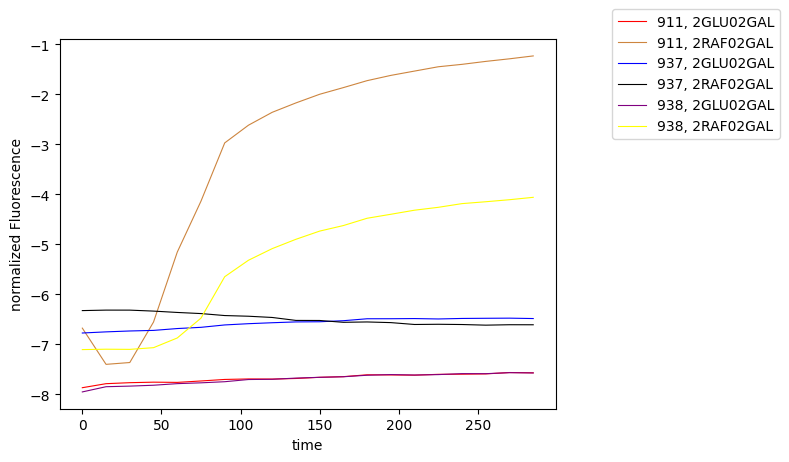

In [88]:
# your code here
fig, ax = plt.subplots() #

#change the value inside the set_index function
means.set_index('time').plot(color=colors, ax=ax, linewidth=.8)

# Change to location of the legend. 
plt.legend(bbox_to_anchor=(1.1, 1.1), bbox_transform=ax.transAxes)
ax.set_ylabel('normalized Fluorescence')

#uncomment the line below to save the image
plt.savefig('flowcyto_over_time.png')

Describe what you see:

 - Are there differences between the three strains?
 911 and 938 show both a clear increase in fluorescence signal with 2RAF02GAL, while 937 remains equal over time no matter the medium.
 937 DOA1-mScarlet expression in under DOA1 endogenous promoter, instead of GAL1 promoter, therefore its expression doesn't depend on galactose presence.
 Moreover, 911 in RAF experiences a initial lag typical of induction.
    
 - Are there differences between the conditions?
 Induction only occurs in the transition from 2RAF02GAL in 911 and 938, in 2GLU02GAL none strain experience induction, this is what we expect as with glucose cells are under catabolic repression over GAL.
 

# distributions

in general, we are expecting log-normal distributions, so let's do a transformation on one of the strain + condition combinations which mean fluorescence seems to increase over time:

Let's first look at the strain / condition combination where something interesting seems to occur!

In [89]:
sel_strain='911' # fill in which strain you want to look at
sel_transition= '2RAF02GAL' # '2RAF2GAL # fill in which condition you want to look at
sel_time = 0 # we will look at the first timepoint

In [90]:
df = comb_df[
(comb_df['strain']==sel_strain) &
(comb_df['transition']==sel_transition) &
(comb_df['time']==sel_time)
]

/opt/miniconda3/envs/quant/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/miniconda3/envs/quant/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Text(0.5, 0, 'fluorescence (log)')

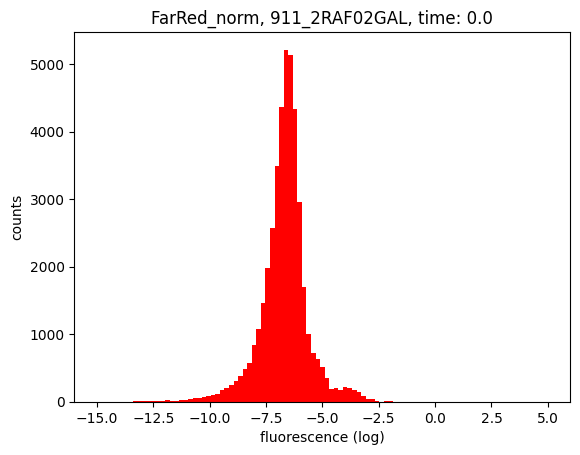

In [91]:
plt.hist(np.log(df[channel]), bins=np.linspace(-15,5, 100), color='red'); 
# np.linspace(0,15,100) gives us 100 evenly spaced values between 0 and 15
# Note it might be necesarry to change the values in linspace.

plt.title(f'{channel}, {df.strain.values[0]}_{df.transition.values[0]}, time: {df.time.values[0]}')
plt.ylabel('counts')
plt.xlabel('fluorescence (log)')

Now lets look at the next time point of this sample.

Text(0.5, 0, 'fluorescence (log)')

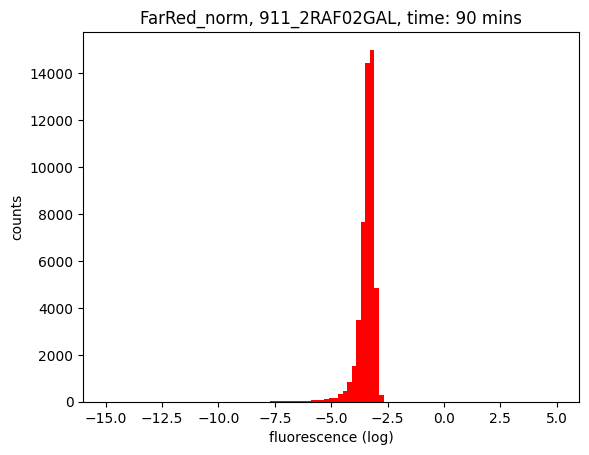

In [92]:
df = comb_df[
(comb_df['strain']==sel_strain) &
(comb_df['transition']==sel_transition) &
(comb_df['time']==90)
]

# let's now look at a later timepoint
plt.hist(np.log(df[channel]), bins=np.linspace(-15, 5, 100), color='red'); 
# np.linspace(0,15,100) gives us 100 evenly spaced values between 0 and 15
# Note it might be necesarry to change the values in linspace.

plt.title(f'{channel}, {sel_strain}_{sel_transition}, time: 90 mins')
plt.ylabel('counts')
plt.xlabel('fluorescence (log)')

Is the observed shift to be expected?

Yes, in 911 mScarlet in under GAL1 promoter, in the change from RAF to GAL, without any repression, GAL1 promoter gets active, therefore, as shown in the histogram, we expect a shift over time towards more fluorescence.
Moreover, the distribution at time=90 narrows, so most of the population responds equally.

Can this shift be observed in the other strains / conditions?

Only partially, this shift should appear in the strains in which mScarlet in under GAL1 (911 and 938), and only in the 2RAF02GAL transition, not in 937, where DOA1-mScarlet in under DOA1 endogenous promoter, neither in 2GLU02GAL transtion due to catabolic repression.

# let's now look at all timepoints for these experiments together

Next we will use matplotlib subplots to plot all our time series data of the entire induction experiment. 
Multiplot subplots often involve nested for loops, which are complicated to understand. Take your time to understand what is happenning in the code below. Then try to interpret the resulting plots.

First, we will define a function to clean up our image labels and ticklabels.

In [93]:
def clean_up_mulitplot(axes,y,x):
    #cleaning up the figure
    #add title headings to the top of the column and remove ticklabels
    if y==0:
        axes[y,x].set_title(f'{strain}: {transition}')

    if x!=0:
        axes[y,x].set_yticklabels('')

    if y!=len(comb_df.time.unique())-1:
        axes[y,x].set_xticklabels('')

Next we will create our multiplot by iterating over the different condition, strain and time combinations.

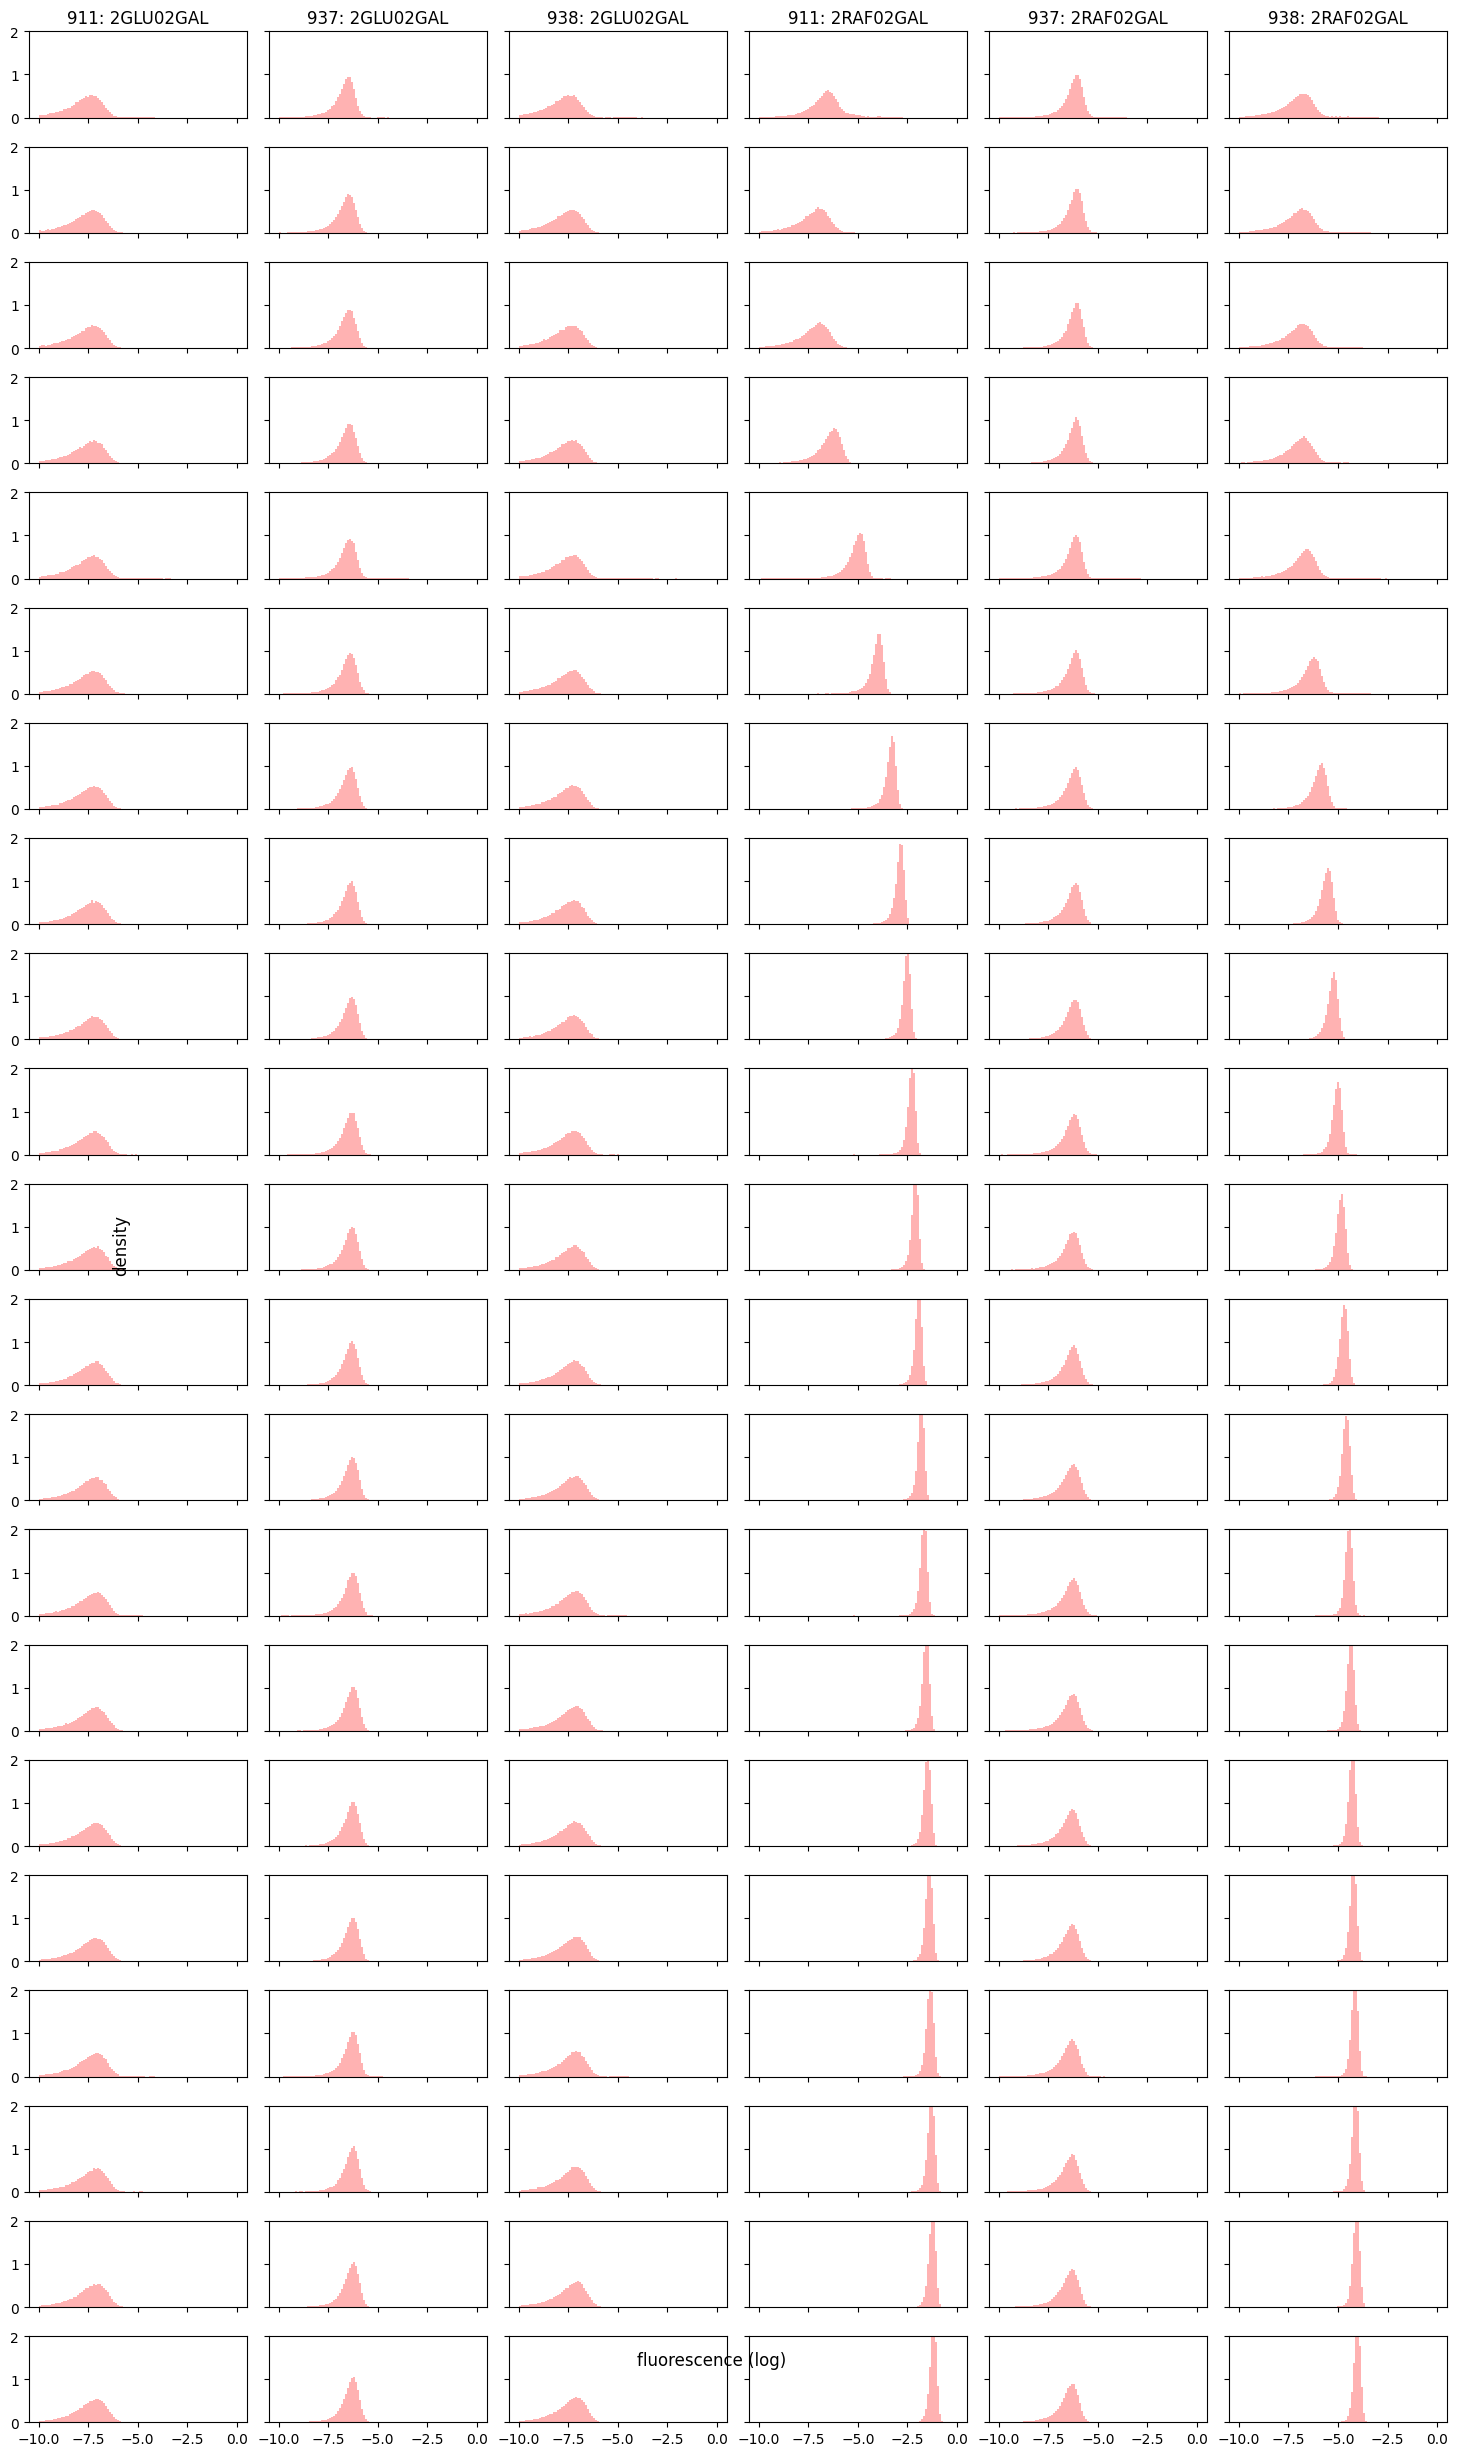

In [94]:
#create a grid
nrows=len(comb_df.time.unique())
#create a list with different time + strain combinations
transition_strain_combs=list(itertools.product(comb_df.transition.unique(),comb_df.strain.unique()))
#this is the different columns we need for our dataframe
ncols=len(transition_strain_combs)

# channel:
channel='FarRed_norm'

fig,axes=plt.subplots(nrows=nrows,ncols=ncols,figsize=(15,25), facecolor='white')

for (transition, strain),x in zip(transition_strain_combs,range(ncols)):
    
    df = comb_df[
        (comb_df['transition']==transition)
        & (comb_df['strain']==strain)
    ]
    
    for time,y in zip(sorted(comb_df.time.unique()),range(nrows)):
                      
        sT_df=df[df['time']==time]
        sT_df = sT_df[sT_df[channel]>0]
        
        #create the plot
        axes[y,x].hist(np.log(sT_df[channel]), bins=np.linspace(-10, 0, 100), alpha=0.3, density=True, color='red')
        
        #make sure the ylim is same for each plot
        axes[y,x].set_ylim(0,2)
        
        #call the image_clean_up function
        clean_up_mulitplot(axes,y,x)
        

            
#add one giant ylabel and xlabel
fig.supxlabel('fluorescence (log)',y=0.05)
fig.supylabel('density', x=0.1)

plt.tight_layout()

#uncomment the following line to save your image
plt.savefig('multiplot_induction.png')

 - what can we conclude from the changes in the distributions over time?

With the distributions we can see the induction at population level, strains with mScarlet under GAL1 reporter (911 and 938) in 2RAF02GAL transition show a moving fluorescence peak over time, moving towards higher values and a narrow distribution, suggesting a unimodal response.
Moreover, 911 strain, being a direct reporter of GAL1 activity, show higher values than 938, and 2GLU02GAL show a static distribution, as well as 937 strain.

####  your turn to code:

- Repeat the analysis for the other induction experiment dataset (hint look at the paths variable at the beginning of the notebook). 

When comparing 0.2% and 2% galactose the results are similar, as the same strains are induced in a similar magnitude, this suggests that 0.2% galactose is enough to saturate GAL1 promoter activation.

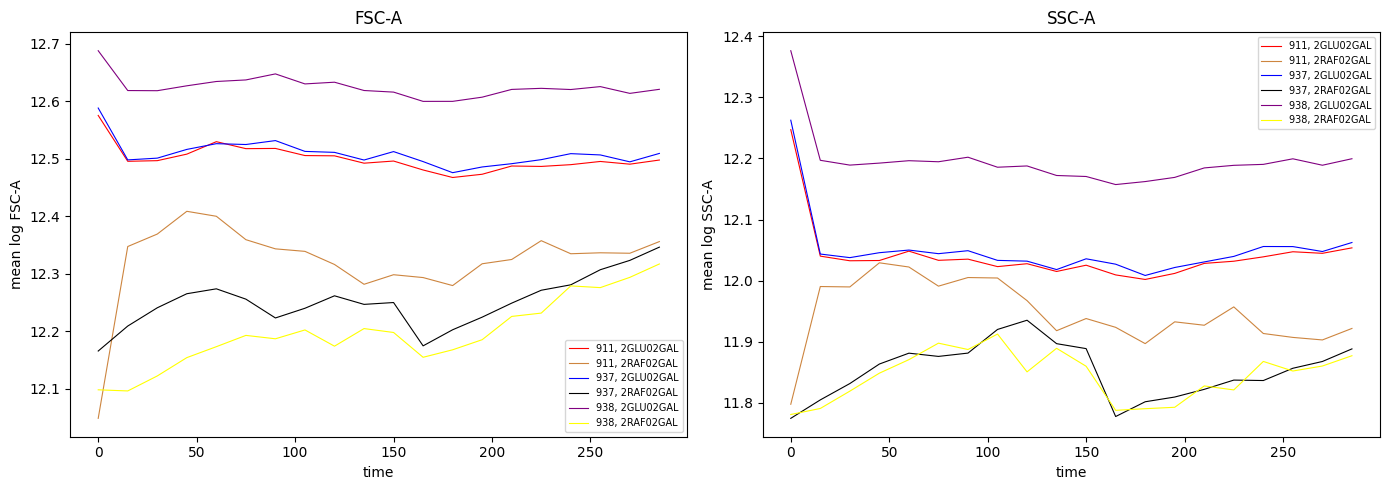

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for channel, ax in zip(['FSC-A', 'SSC-A'], axes):

    means_morph = pd.DataFrame()
    for sel_strain in comb_df['strain'].unique():
        for sel_transition in comb_df['transition'].unique():
            sample_means = []
            for sel_time in sorted(comb_df['time'].unique()[:-1]):
                df = comb_df[
                    (comb_df['strain']==sel_strain) &
                    (comb_df['transition']==sel_transition) &
                    (comb_df['time']==sel_time)
                ]
                df = df[df[channel]>0]
                sample_means.append(np.mean(np.log(df[channel])))
            means_morph[f'{sel_strain}, {sel_transition}'] = sample_means
    means_morph['time'] = sorted(comb_df['time'].unique())[:-1]

    means_morph.set_index('time').plot(color=colors, ax=ax, linewidth=.8)
    ax.set_title(channel)
    ax.set_ylabel(f'mean log {channel}')
    ax.legend(fontsize=7)

plt.tight_layout()
#plt.savefig('morphology_over_time.png')

- How do the morphological channels change over time?

FSC-A and SSC-A (Area) change clustered by condition but no by strain, therefore morphology depends on the metabolic state and not the expression of the reporter.

Moreover, cells growth in glucose start from a larger volume and complexity and stay overall constant. Raffinose growth cells start from a smaller overall volume and then increase progressively FSC and SSC overtime when re-adapted to galactose.

Type your answer here.

# let's now look at all control experiment data and the additional timepoint measured after 16 hours of growth

Now let's look at our control experiments. These samples were either transitioned to galactose and measured after 16 hours or where not transitioned at all and measured.

### your turn:
What is the purpose of these different control strains?

Samples without the transition are used as a negative control to obtain the basal fluorescence of each strain, 16 hours Galactose transitions are used as a positive control as a maximum.

858 strain is a wild-type without mScarlet, is shows the basal autofluorescence of the cytometer, therefore the background noise.

In [102]:
path=Path('practical data','Full induction control_GLU or RAF to GALON_911_937_938').glob('*.csv')

files=sorted(path)
os.path.basename(files[1])

'858_2GLU2GAL.csv'

In [103]:
dfs=[]
    
for file in files:

    #get meta-data from filename for first two replicates
    #get meta-data from filename for two induction experiments
    strain, transition = Path(file).stem.split('_')

    #load data in pandas dataframe and add meta-data to frame
    df=pd.read_csv(file)
    df['strain']=strain
    df['transition']=transition
    df['time']=0
    dfs.append(df)
    
ctrl_df=pd.concat(dfs)
ctrl_df=pd.concat(dfs).reset_index(drop=True)
ctrl_df = ctrl_df[ctrl_df.columns[1:]]

# forward scatter correlates strongly with particle size. 
# to scale absolute fluorescence values to a concentration, divide each cell's fluorescence value
# by that cell's FSC value.
ctrl_df['FarRed_norm'] = ctrl_df['FarRed-561nm-A'] / ctrl_df['FSC-A']

### Now your turn to code!

- inspect the unique values contained in each column of the control dataframe.

In [104]:
for col in ['strain', 'transition', 'time']:
    print(col, ctrl_df[col].unique())

strain ['858' '911' '937' '938']
transition ['2GLU' '2GLU2GAL' '2RAF' '2RAF2GAL']
time [0]


# Plot the control dataframe

In [105]:
nrows=len(ctrl_df.strain.unique())
ncols=len(ctrl_df.transition.unique())

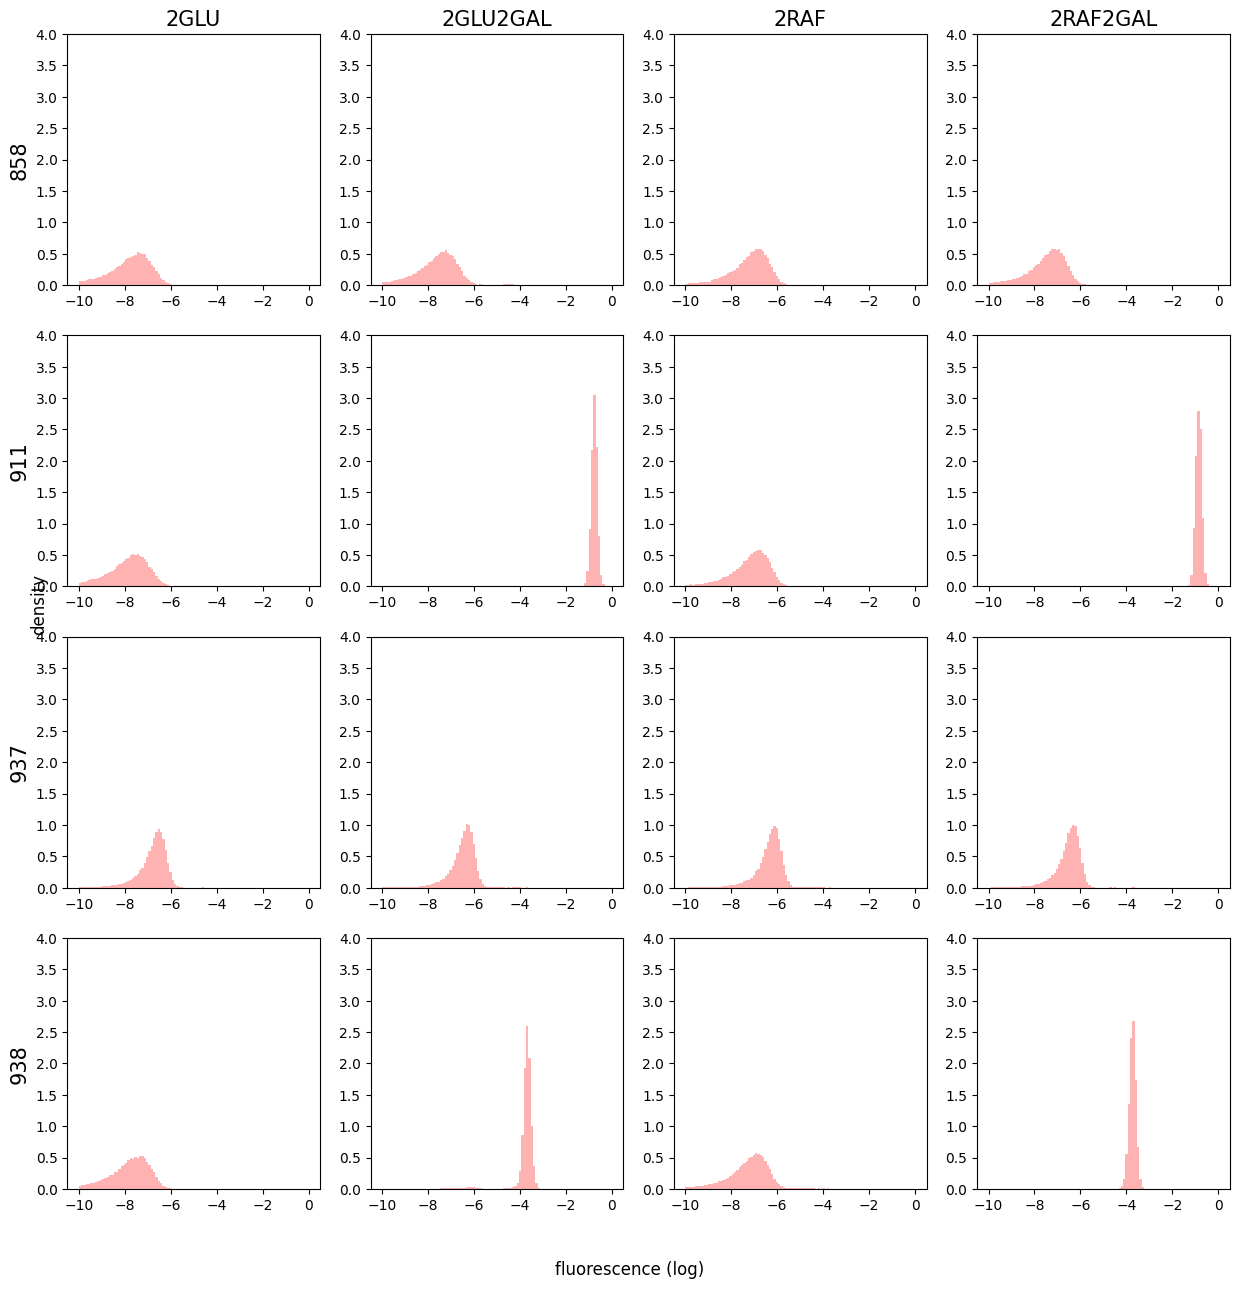

In [107]:
#create a grid
nrows=len(ctrl_df.strain.unique())
ncols=len(ctrl_df.transition.unique())

# channel:
channel='FarRed_norm'

fig,axes=plt.subplots(nrows=nrows,ncols=ncols,figsize=(15,15), facecolor='white')

for transition,x in zip(sorted(ctrl_df.transition.unique()),range(ncols)):
    
    for strain,y in zip(sorted(ctrl_df.strain.unique()),range(nrows)):
                      
        df = ctrl_df[
        (ctrl_df['transition']==transition)
        & (ctrl_df['strain']==strain)
        ]
        
        df = df[df[channel]>0]
        
        axes[y,x].hist(np.log(df[channel]), bins=np.linspace(-10, 0, 100), alpha=0.3, density=True, color='red')
        
        #make sure y range is the same for each plot
        axes[y,x].set_ylim(0,4)
        
        #add title headings to the top of the columns and each row.
        if y==0:
            axes[y,x].set_title(f'{transition}',size=15)
        if x==0:
            axes[y,x].set_ylabel(f'{strain}',size=15)
            
fig.supxlabel('fluorescence (log)',y=0.05)
fig.supylabel('density', x=0.1)

#uncomment the following line to save your image
plt.savefig('multiplot_control.png')

### your turn:
- what can we learn from these control strains?

858 strain stays stable in the four conditions, being the background fluorescence. 
937 show a peak independently of galactose, not being inducibe by GAL1 reporter.
911 and 938 strains show a clear difference in fluoresence between glucose and raffinose only mediums and galactose transition mediums.
In this way we can study the whole spectrum of the induction and check that it only occurs under galactose with the reporter under GAL1 promoter control.
Another relevant finding is that transitions starting from glucose show induction at 16 hours, in contrast with the earlier stages when catabolic repression is on.

- How do they compare to the other induction experiments?

The main difference is that after 16 hours the catabolic repression is already gone and transitions from glucose are able to show induction.

## your turn:

Can you recreate the multiplots above for the induction experiment but instead use scatterplot() function to plot FarRed-561nm-A vs. FSC-A. Make sure to log tranform both x and y variable.

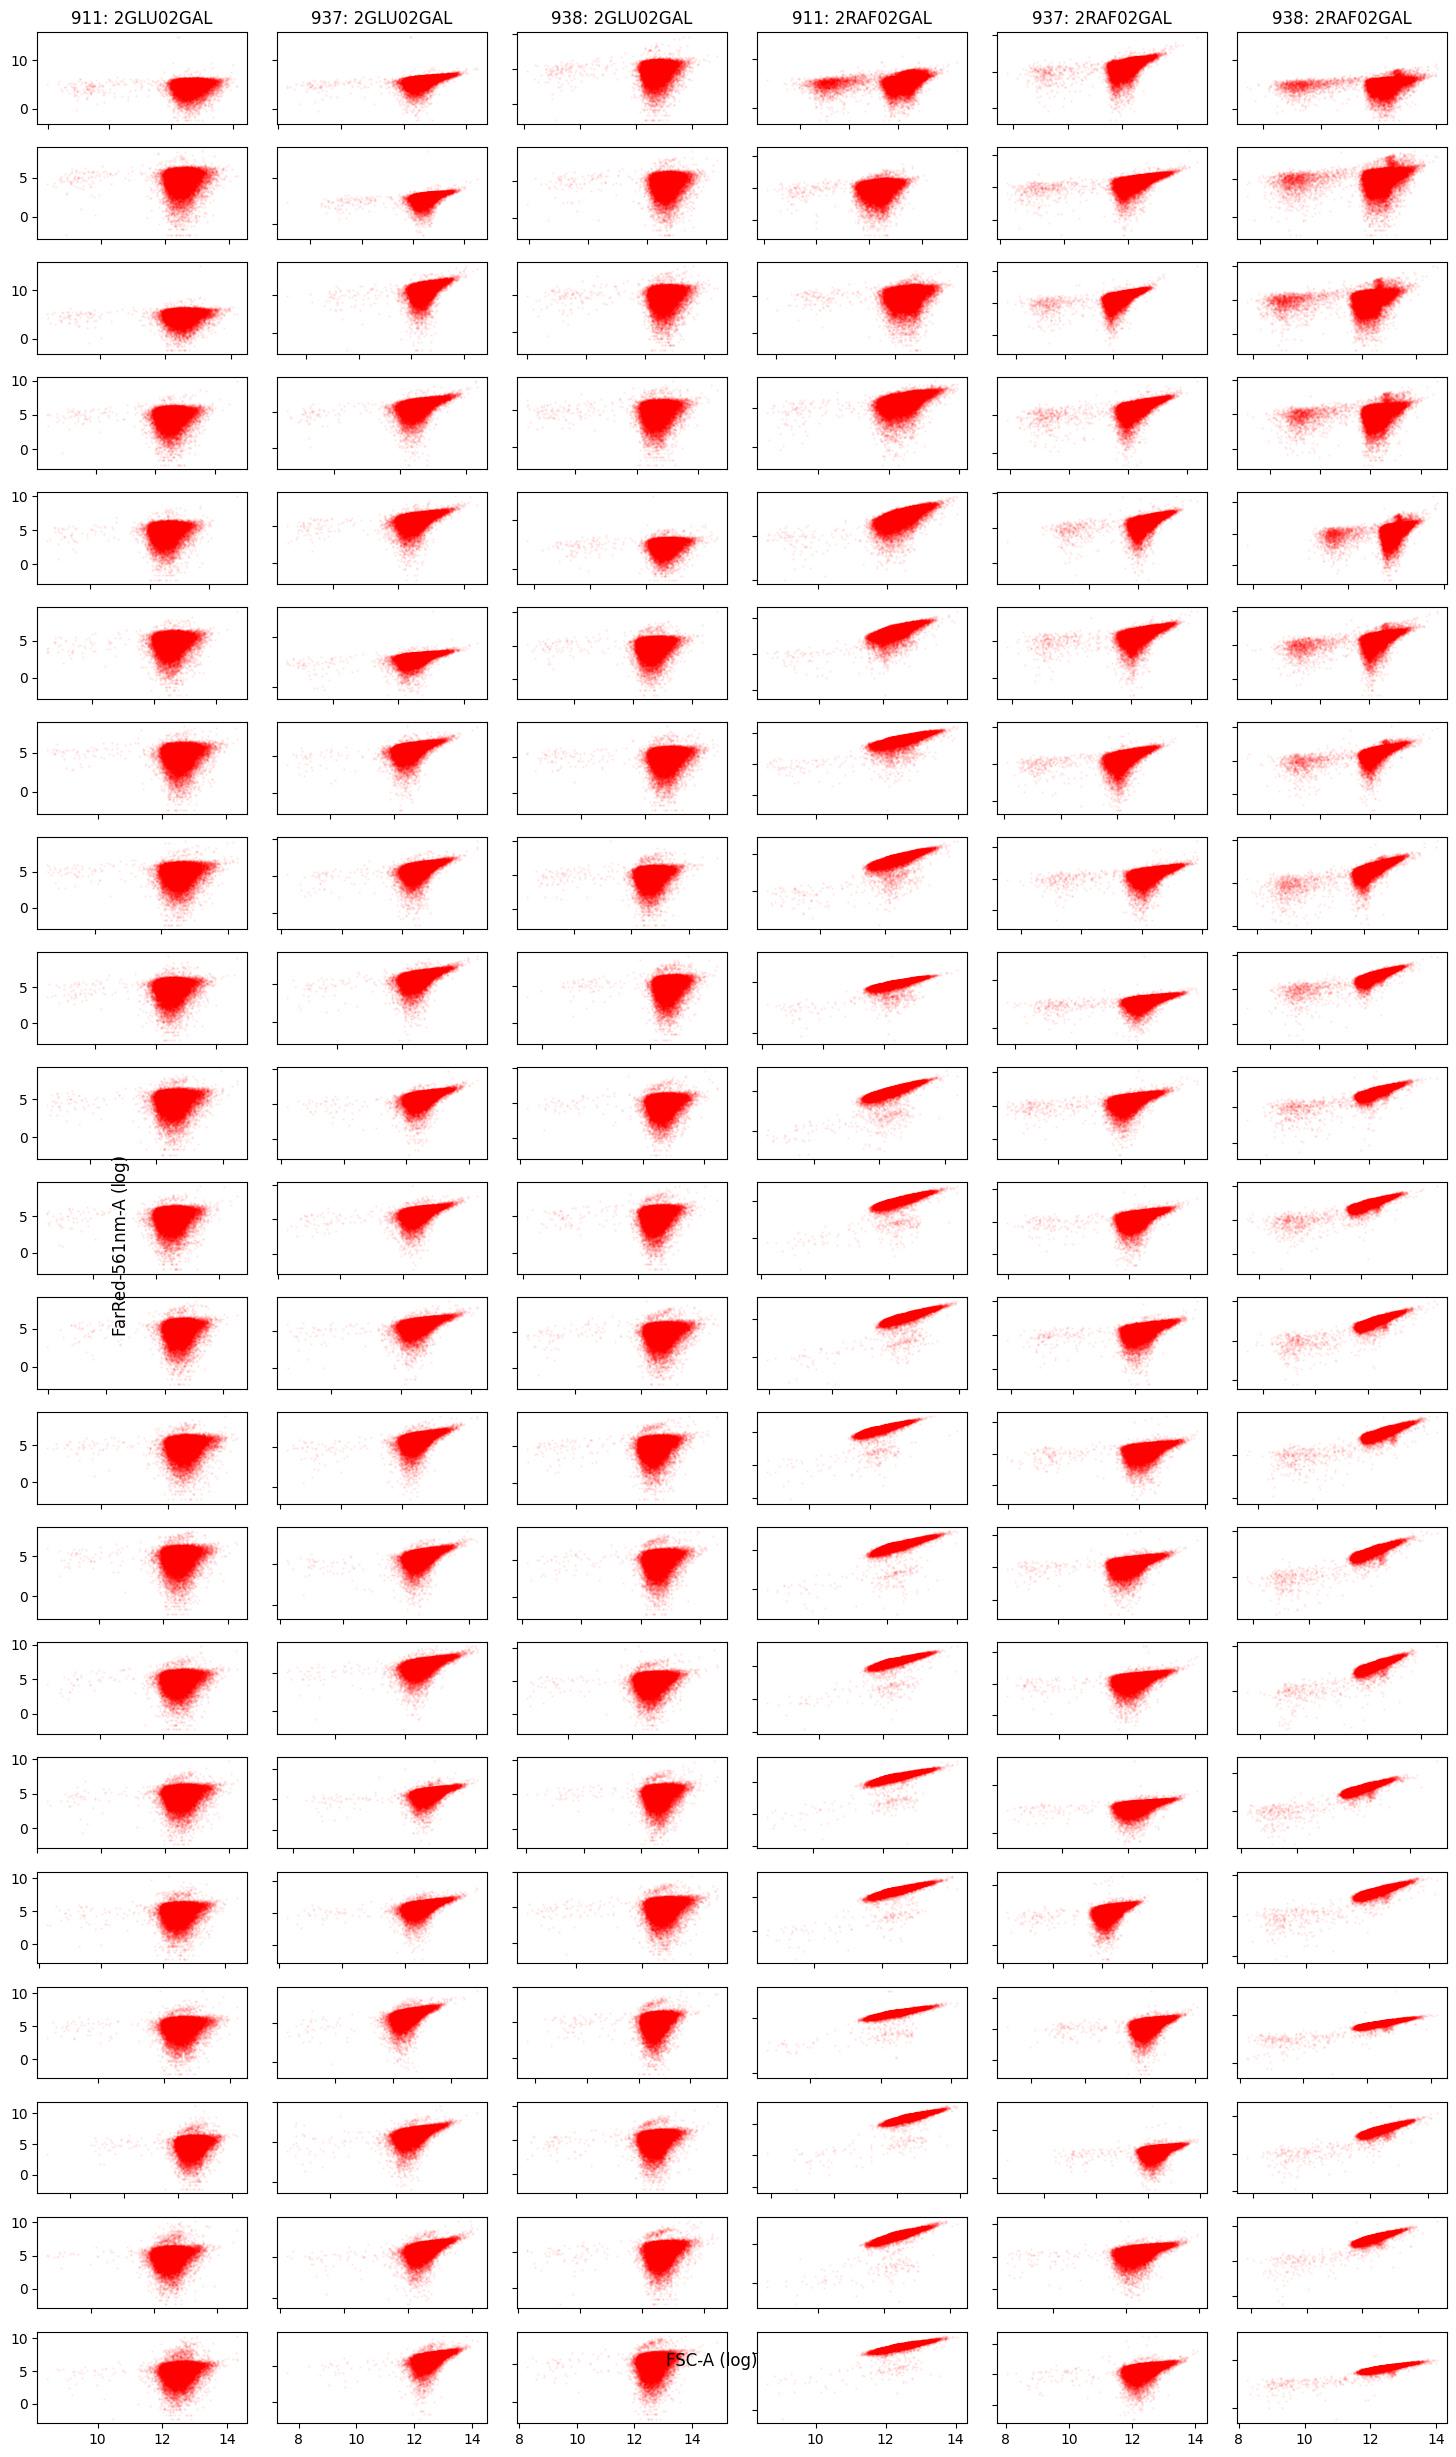

In [108]:
nrows=len(comb_df.time.unique())
transition_strain_combs=list(itertools.product(comb_df.transition.unique(),comb_df.strain.unique()))
ncols=len(transition_strain_combs)

fig,axes=plt.subplots(nrows=nrows,ncols=ncols,figsize=(15,25), facecolor='white')

for (transition, strain),x in zip(transition_strain_combs,range(ncols)):

    df = comb_df[
        (comb_df['transition']==transition)
        & (comb_df['strain']==strain)
    ]

    for time,y in zip(sorted(comb_df.time.unique()),range(nrows)):

        sT_df=df[df['time']==time]
        sT_df = sT_df[(sT_df['FarRed-561nm-A']>0) & (sT_df['FSC-A']>0)]

        axes[y,x].scatter(
            np.log(sT_df['FSC-A']),
            np.log(sT_df['FarRed-561nm-A']),
            s=1, alpha=0.05, color='red'
        )

        clean_up_mulitplot(axes,y,x)

fig.supxlabel('FSC-A (log)', y=0.05)
fig.supylabel('FarRed-561nm-A (log)', x=0.1)

plt.tight_layout()
plt.savefig('multiplot_scatter_induction.png')

- What are we comparing in this plot?

We compare the raw mScarlet fluorescence cell per cell (y-axis), without normalizing it, and the cell size (x-axis)

# Extra coding assignment

- Recreate the multiplots above using the seaborn plotting library instead

In [ ]:
#Code here

***

You finished the practical! Make sure to carefully interpret the results and save the resulting figures for your report.